In [1]:
!pip install tensorflow numpy matplotlib pandas scikit-learn --quiet

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time
from sklearn.model_selection import train_test_split

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.19.0


In [2]:
# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

print("Train shape:", x_train.shape, y_train.shape)
print("Test shape:", x_test.shape, y_test.shape)

# Normalize pixel values
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Create validation split
x_train, x_val, y_train, y_val = train_test_split(
    x_train, y_train, test_size=0.1, random_state=42, stratify=y_train
)

# One-hot encode labels
num_classes = 10
y_train_cat = keras.utils.to_categorical(y_train, num_classes)
y_val_cat = keras.utils.to_categorical(y_val, num_classes)
y_test_cat = keras.utils.to_categorical(y_test, num_classes)

print("Training samples:", x_train.shape[0])
print("Validation samples:", x_val.shape[0])
print("Testing samples:", x_test.shape[0])


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Train shape: (50000, 32, 32, 3) (50000, 1)
Test shape: (10000, 32, 32, 3) (10000, 1)
Training samples: 45000
Validation samples: 5000
Testing samples: 10000


/tmp/ipython-input-2823072738.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(class_names[int(y_train[i])])


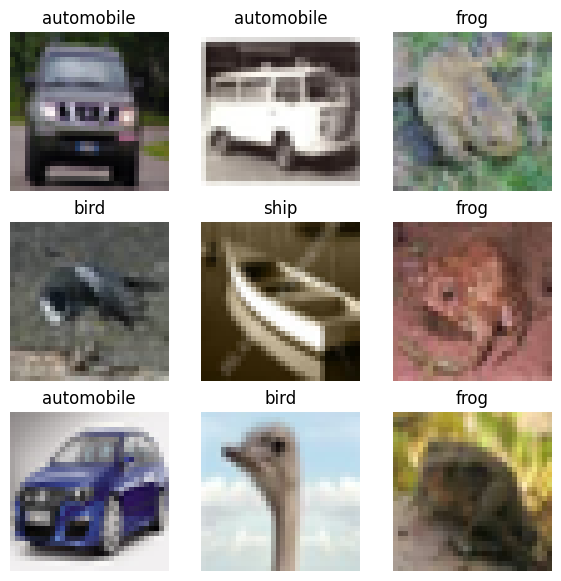

Example image array (first sample):
[[[0.12156863 0.18431373 0.08235294]
  [0.11372549 0.16078432 0.08627451]
  [0.10588235 0.11764706 0.09411765]
  ...
  [0.05490196 0.07450981 0.05490196]
  [0.05490196 0.07450981 0.05098039]
  [0.06666667 0.08627451 0.0627451 ]]

 [[0.15294118 0.21568628 0.10196079]
  [0.11372549 0.14901961 0.07843138]
  [0.10196079 0.1254902  0.07843138]
  ...
  [0.06666667 0.08627451 0.0627451 ]
  [0.0627451  0.08235294 0.05490196]
  [0.05098039 0.06666667 0.04313726]]

 [[0.16078432 0.22352941 0.10588235]
  [0.16078432 0.21568628 0.10196079]
  [0.11372549 0.16470589 0.07058824]
  ...
  [0.08235294 0.11372549 0.07843138]
  [0.0627451  0.09411765 0.05882353]
  [0.07450981 0.09019608 0.06666667]]

 ...

 [[0.49803922 0.45490196 0.4392157 ]
  [0.49803922 0.44313726 0.43137255]
  [0.48235294 0.41960785 0.42352942]
  ...
  [0.54509807 0.49803922 0.5058824 ]
  [0.5411765  0.49411765 0.49803922]
  [0.53333336 0.4862745  0.47843137]]

 [[0.4862745  0.44313726 0.42745098]
 

In [3]:
# CIFAR-10 class labels
class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

# Display sample images
plt.figure(figsize=(7,7))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[int(y_train[i])])
    plt.axis('off')
plt.show()

# Print one image array to show pixel representation
print("Example image array (first sample):")
print(x_train[0])


In [4]:
# Model structure:
# Input layer: flattened 32x32x3 = 3072 neurons
# Hidden layer 1: 512 neurons (ReLU)
# Hidden layer 2: 256 neurons (ReLU)
# Output layer: 10 neurons (Softmax)
def build_dense_model(input_shape=(32, 32, 3), num_classes=10, dropout=0.5):
    model = models.Sequential([
        layers.Flatten(input_shape=input_shape),
        layers.Dense(512, activation='relu'),
        layers.Dropout(dropout),
        layers.Dense(256, activation='relu'),
        layers.Dropout(dropout),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

dense_model = build_dense_model()
dense_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# Model structure:
# Conv layers capture spatial features
# Pooling reduces spatial size
# Fully connected layers classify
def build_cnn_model(input_shape=(32, 32, 3), num_classes=10, dropout=0.25):
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(dropout),

        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(dropout),

        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

cnn_model = build_cnn_model()
cnn_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,168,362 (8.27 MB)

 Trainable params: 2,168,362 (8.27 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
def plot_history(history, title="Training History"):
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Val')
    plt.title(f'{title} - Accuracy')
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Val')
    plt.title(f'{title} - Loss')
    plt.legend()
    plt.show()


def train_and_evaluate(model, x_train, y_train, x_val, y_val, x_test, y_test, batch_size, epochs, lr):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    start = time.time()
    history = model.fit(
        x_train, y_train,
        validation_data=(x_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        verbose=2
    )
    train_time = time.time() - start
    train_acc = history.history['accuracy'][-1]
    val_acc   = history.history['val_accuracy'][-1]
    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
    return train_acc, val_acc, test_acc, train_time, history

In [13]:
# Define experiment configurations (5 iterations)
experiments = [
    {'model_type': 'dense', 'batch': 64,  'epochs': 10, 'lr': 0.001, 'dropout': 0.5},
    {'model_type': 'dense', 'batch': 128, 'epochs': 15, 'lr': 0.001, 'dropout': 0.5},
    {'model_type': 'cnn',   'batch': 64,  'epochs': 10, 'lr': 0.001, 'dropout': 0.25},
    {'model_type': 'cnn',   'batch': 128, 'epochs': 15, 'lr': 0.001, 'dropout': 0.25},
    {'model_type': 'cnn',   'batch': 128, 'epochs': 20, 'lr': 0.0005, 'dropout': 0.3},
    {'model_type': 'cnn',   'batch': 256, 'epochs': 10, 'lr': 0.0001, 'dropout': 0.2},
    {'model_type': 'cnn',   'batch': 256, 'epochs': 10, 'lr': 0.001, 'dropout': 0.2},
    {'model_type': 'cnn',   'batch': 128, 'epochs': 20, 'lr': 0.0005, 'dropout': 0.5}
]

results = []

for exp in experiments:
    print(f"\\nRunning experiment: {exp}")
    model = build_dense_model(dropout=exp['dropout']) if exp['model_type']=='dense' else build_cnn_model(dropout=exp['dropout'])
    train_acc, val_acc, test_acc, t_time, hist = train_and_evaluate(
        model, x_train, y_train_cat, x_val, y_val_cat, x_test, y_test_cat,
        exp['batch'], exp['epochs'], exp['lr']
    )
    results.append({
        'Model': exp['model_type'].upper(),
        'Batch Size': exp['batch'],
        'Epochs': exp['epochs'],
        'Learning Rate': exp['lr'],
        'Dropout': exp['dropout'],
        'Train Accuracy': round(train_acc, 4),
        'Validation Accuracy': round(val_acc, 4),
        'Test Accuracy': round(test_acc, 4),
        'Time (s)': round(t_time, 2)
    })

# Save results
results_df = pd.DataFrame(results)
print(results_df)
results_df.to_csv("assignment3_results.csv", index=False)


\nRunning experiment: {'model_type': 'dense', 'batch': 64, 'epochs': 10, 'lr': 0.001, 'dropout': 0.5}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
704/704 - 7s - 10ms/step - accuracy: 0.1665 - loss: 2.1834 - val_accuracy: 0.2632 - val_loss: 2.0153
Epoch 2/10
704/704 - 2s - 3ms/step - accuracy: 0.1986 - loss: 2.0958 - val_accuracy: 0.2736 - val_loss: 2.0256
Epoch 3/10
704/704 - 2s - 3ms/step - accuracy: 0.2095 - loss: 2.0624 - val_accuracy: 0.2908 - val_loss: 2.0095
Epoch 4/10
704/704 - 2s - 3ms/step - accuracy: 0.2184 - loss: 2.0440 - val_accuracy: 0.2676 - val_loss: 1.9906
Epoch 5/10
704/704 - 2s - 3ms/step - accuracy: 0.2266 - loss: 2.0371 - val_accuracy: 0.2978 - val_loss: 1.9830
Epoch 6/10
704/704 - 2s - 3ms/step - accuracy: 0.2306 - loss: 2.0315 - val_accuracy: 0.2480 - val_loss: 2.0131
Epoch 7/10
704/704 - 2s - 3ms/step - accuracy: 0.2303 - loss: 2.0257 - val_accuracy: 0.2500 - val_loss: 2.0070
Epoch 8/10
704/704 - 2s - 3ms/step - accuracy: 0.2285 - loss: 2.0290 - val_accuracy: 0.2762 - val_loss: 2.0116
Epoch 9/10
704/704 - 2s - 3ms/step - accuracy: 0.2321 - loss: 2.0218 - val_accuracy: 0.2892 - val_loss: 1.9874


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 - 13s - 19ms/step - accuracy: 0.4392 - loss: 1.5315 - val_accuracy: 0.5828 - val_loss: 1.1404
Epoch 2/10
704/704 - 5s - 7ms/step - accuracy: 0.5935 - loss: 1.1373 - val_accuracy: 0.6570 - val_loss: 0.9710
Epoch 3/10
704/704 - 5s - 7ms/step - accuracy: 0.6610 - loss: 0.9612 - val_accuracy: 0.6942 - val_loss: 0.8598
Epoch 4/10
704/704 - 5s - 7ms/step - accuracy: 0.6985 - loss: 0.8535 - val_accuracy: 0.7308 - val_loss: 0.7568
Epoch 5/10
704/704 - 5s - 7ms/step - accuracy: 0.7316 - loss: 0.7712 - val_accuracy: 0.7552 - val_loss: 0.6893
Epoch 6/10
704/704 - 5s - 7ms/step - accuracy: 0.7512 - loss: 0.7127 - val_accuracy: 0.7484 - val_loss: 0.7111
Epoch 7/10
704/704 - 4s - 6ms/step - accuracy: 0.7655 - loss: 0.6659 - val_accuracy: 0.7422 - val_loss: 0.7304
Epoch 8/10
704/704 - 5s - 7ms/step - accuracy: 0.7790 - loss: 0.6216 - val_accuracy: 0.7772 - val_loss: 0.6309
Epoch 9/10
704/704 - 4s - 6ms/step - accuracy: 0.7944 - loss: 0.5823 - val_accuracy: 0.7688 - val_loss: 0.6656

Epoch 1/20
352/352 - 6s - 18ms/step - accuracy: 0.1815 - loss: 2.1642 - val_accuracy: 0.2778 - val_loss: 1.9995
Epoch 2/20
352/352 - 1s - 3ms/step - accuracy: 0.1965 - loss: 2.0836 - val_accuracy: 0.2880 - val_loss: 1.9711
Epoch 3/20
352/352 - 1s - 3ms/step - accuracy: 0.2043 - loss: 2.0650 - val_accuracy: 0.2990 - val_loss: 1.9565
Epoch 4/20
352/352 - 1s - 3ms/step - accuracy: 0.2246 - loss: 2.0313 - val_accuracy: 0.3046 - val_loss: 1.9733
Epoch 5/20
352/352 - 1s - 3ms/step - accuracy: 0.2384 - loss: 2.0031 - val_accuracy: 0.3248 - val_loss: 1.9211
Epoch 6/20
352/352 - 1s - 3ms/step - accuracy: 0.2445 - loss: 1.9932 - val_accuracy: 0.3272 - val_loss: 1.9445
Epoch 7/20
352/352 - 1s - 3ms/step - accuracy: 0.2411 - loss: 1.9924 - val_accuracy: 0.3022 - val_loss: 1.9442
Epoch 8/20
352/352 - 1s - 3ms/step - accuracy: 0.2472 - loss: 1.9836 - val_accuracy: 0.2954 - val_loss: 1.9756
Epoch 9/20
352/352 - 1s - 4ms/step - accuracy: 0.2535 - loss: 1.9783 - val_accuracy: 0.3280 - val_loss: 1.9260


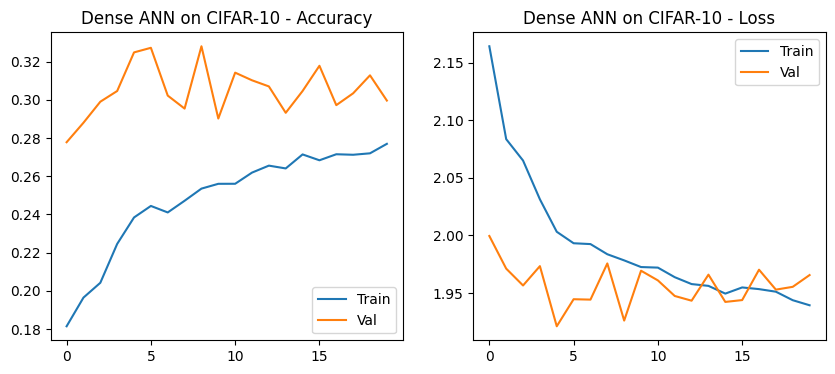

In [10]:
train_acc_dense, val_acc_dense, test_acc_dense, t_time_dense, history_dense = train_and_evaluate(
    dense_model,
    x_train, y_train_cat,
    x_val, y_val_cat,
    x_test, y_test_cat,
    batch_size=128,
    epochs=20,
    lr=0.001
)
plot_history(history_dense, "Dense ANN on CIFAR-10")

Epoch 1/20
352/352 - 14s - 39ms/step - accuracy: 0.4018 - loss: 1.6343 - val_accuracy: 0.5752 - val_loss: 1.2203
Epoch 2/20
352/352 - 4s - 11ms/step - accuracy: 0.5798 - loss: 1.1768 - val_accuracy: 0.6442 - val_loss: 0.9810
Epoch 3/20
352/352 - 4s - 11ms/step - accuracy: 0.6466 - loss: 0.9962 - val_accuracy: 0.6780 - val_loss: 0.9015
Epoch 4/20
352/352 - 4s - 11ms/step - accuracy: 0.6848 - loss: 0.8845 - val_accuracy: 0.7282 - val_loss: 0.7755
Epoch 5/20
352/352 - 4s - 11ms/step - accuracy: 0.7164 - loss: 0.7966 - val_accuracy: 0.7388 - val_loss: 0.7352
Epoch 6/20
352/352 - 4s - 11ms/step - accuracy: 0.7379 - loss: 0.7370 - val_accuracy: 0.7536 - val_loss: 0.6937
Epoch 7/20
352/352 - 5s - 13ms/step - accuracy: 0.7591 - loss: 0.6851 - val_accuracy: 0.7586 - val_loss: 0.6632
Epoch 8/20
352/352 - 5s - 13ms/step - accuracy: 0.7753 - loss: 0.6334 - val_accuracy: 0.7738 - val_loss: 0.6338
Epoch 9/20
352/352 - 4s - 11ms/step - accuracy: 0.7907 - loss: 0.5940 - val_accuracy: 0.7732 - val_loss

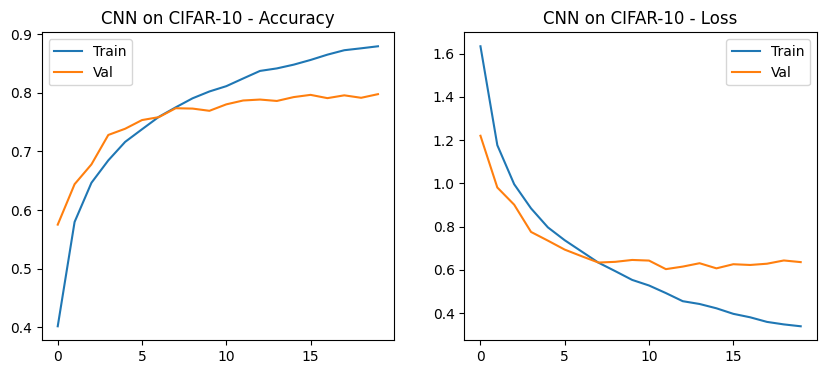

In [11]:
train_acc_cnn, val_acc_cnn, test_acc_cnn, t_time_cnn, history_cnn = train_and_evaluate(
    cnn_model,
    x_train, y_train_cat,
    x_val, y_val_cat,
    x_test, y_test_cat,
    batch_size=128,
    epochs=20,
    lr=0.001 # Changed epochs to 20 and lr to 0.001 to match the best CNN experiment from dfj9SKhGouXi
)
plot_history(history_cnn, "CNN on CIFAR-10")

In [12]:
dense_test_loss, dense_test_acc = dense_model.evaluate(x_test, y_test_cat, verbose=0)
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test, y_test_cat, verbose=0)

print(f"Dense Model Test Accuracy: {dense_test_acc:.4f}")
print(f"CNN Model Test Accuracy:   {cnn_test_acc:.4f}")


Dense Model Test Accuracy: 0.3022
CNN Model Test Accuracy:   0.7910


In [14]:
results = pd.DataFrame([
    {"Model": "Dense ANN", "Batch Size": 128, "Epochs": 20, "LR": 0.001,
     "Train Acc": history_dense.history['accuracy'][-1],
     "Val Acc": history_dense.history['val_accuracy'][-1],
     "Test Acc": dense_test_acc},
    {"Model": "CNN", "Batch Size": 128, "Epochs": 20, "LR": 0.001,
     "Train Acc": history_cnn.history['accuracy'][-1],
     "Val Acc": history_cnn.history['val_accuracy'][-1],
     "Test Acc": cnn_test_acc}
])

print(results)


       Model  Batch Size  Epochs     LR  Train Acc  Val Acc  Test Acc
0  Dense ANN         128      20  0.001   0.276956   0.2996    0.3022
1        CNN         128      20  0.001   0.879489   0.7978    0.7910


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 833ms/step


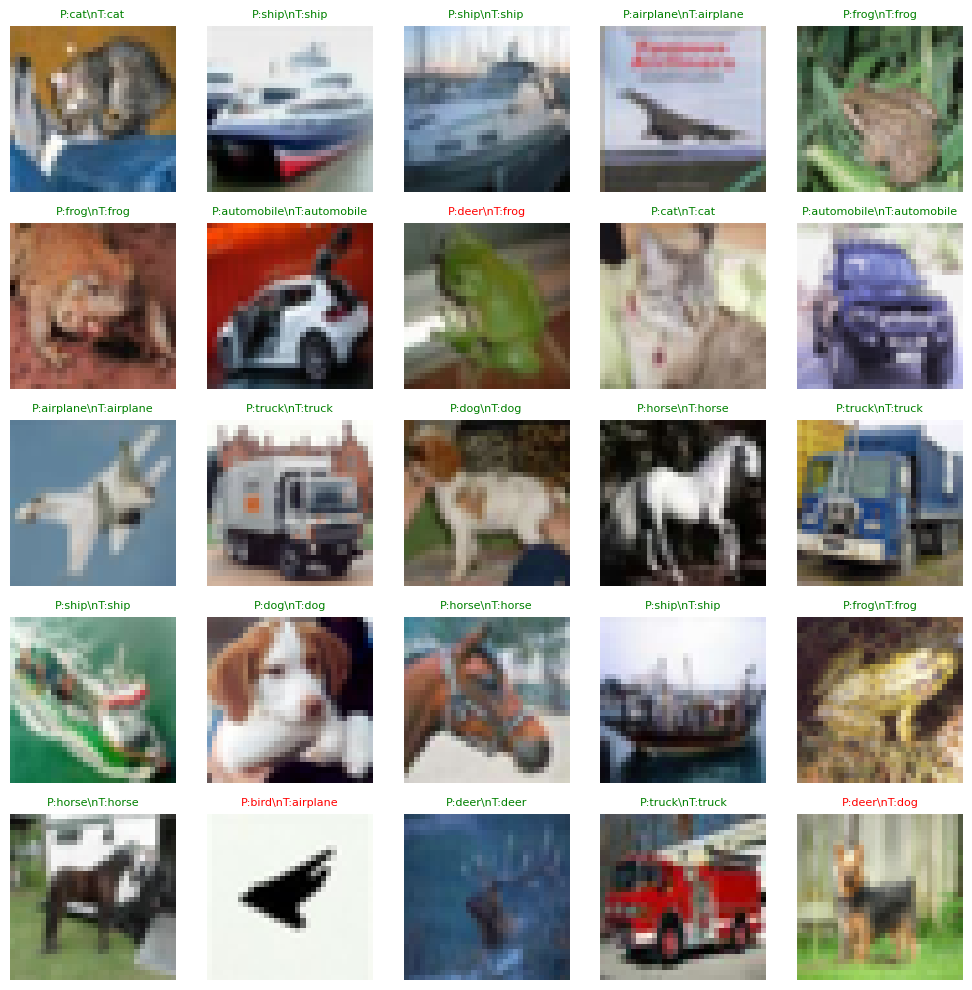

In [15]:
# =========================================
# Visualize predictions on CIFAR-10 samples
# =========================================

# Get model predictions (for CNN by default)
y_pred = cnn_model.predict(x_test[:25])
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = y_test[:25].flatten()

# Plot first 25 test images with predicted vs true labels
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(x_test[i])
    true_label = class_names[y_true[i]]
    pred_label = class_names[y_pred_classes[i]]
    color = 'green' if y_true[i] == y_pred_classes[i] else 'red'
    plt.title(f"P:{pred_label}\\nT:{true_label}", color=color, fontsize=8)
    plt.axis('off')
plt.tight_layout()
plt.show()


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


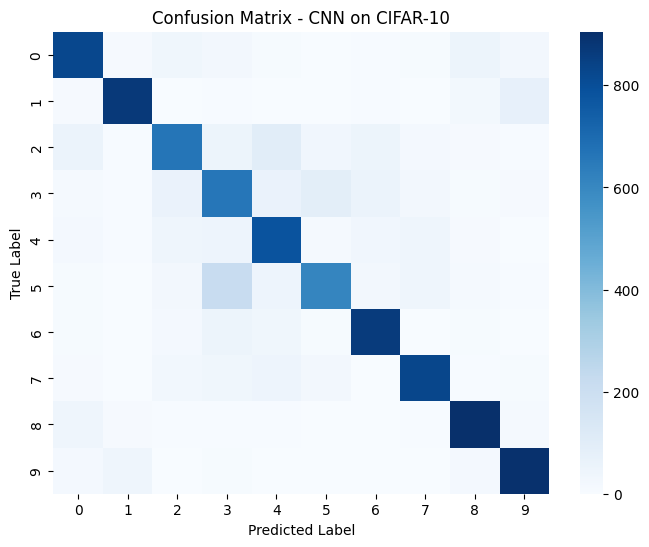

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Predict all test samples
y_pred_all = cnn_model.predict(x_test)
y_pred_classes_all = np.argmax(y_pred_all, axis=1)
y_true_all = y_test.flatten()

# Confusion matrix
cm = confusion_matrix(y_true_all, y_pred_classes_all)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=False, cmap='Blues')
plt.title("Confusion Matrix - CNN on CIFAR-10")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()
